# Aula 3: Otimização Combinatória Não-Linear (MINLP)
## Qual(is) máquina(s) usar na fábrica?

Uma fábrica precisa produzir **10.000 unidades** e tem 3 máquinas disponíveis, cada uma com uma curva de custo diferente:

- **Máquina A**: custo quadrático (`0.001·p² + 2·p`) + custo fixo de ligar (R$ 500)
- **Máquina B**: custo linear (`3·p`) + custo fixo de ligar **alto** (R$ 5.000)
- **Máquina C**: custo cúbico (`0.0000005·p³ + 1.5·p`), sem custo fixo

**Perguntas desta aula:**
1. Vale a pena ligar mais de uma máquina ao mesmo tempo e dividir a produção entre elas?
2. Por que esse problema não é linear (CBC) nem apenas não-linear (Ipopt)?
3. Qual solver resolve um problema com variáveis **binárias** (ligar/desligar) *e* **não-lineares** (as curvas de custo) ao mesmo tempo?

Esse é um problema de **MINLP** (Mixed-Integer NonLinear Programming): decidimos *quais* máquinas ligar (variável binária) e *quanto* produzir em cada uma (variável contínua e não-linear). O solver certo para isso é o **Couenne**, um otimizador global para MINLP.

## 1. Instalação e Configuração do Solver (Couenne)

Assim como na Aula 2 usamos o Ipopt para não-linearidade contínua, aqui precisamos do **Couenne**, que também vem pré-compilado no pacote `idaes-pse`.

O `idaes get-extensions` detecta o sistema operacional automaticamente, mas em alguns ambientes (ex.: containers Debian mais recentes) a detecção falha com `Unsupported platform`. Nesse caso forçamos o download da build `ubuntu2204`, que é compatível (mesma glibc).

In [5]:
import os
import subprocess

import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Instalação do Pyomo e do utilitário IDAES (necessário para baixar os binários do Couenne)
%pip install -q pyomo idaes-pse --pre

# Download dos binários (Couenne, Bonmin, Ipopt, CBC...).
# Se a plataforma não for reconhecida automaticamente, força a build 'ubuntu2204'
# (compatível com a maioria das distros Linux modernas, incluindo Debian recentes).
resultado = subprocess.run(["idaes", "get-extensions"], capture_output=True, text=True)
saida = resultado.stdout + resultado.stderr
if resultado.returncode != 0 or "Unsupported platform" in saida:
    print("Plataforma não reconhecida automaticamente, forçando build 'ubuntu2204'...")
    resultado = subprocess.run(
        ["idaes", "get-extensions", "--distro", "ubuntu2204"],
        capture_output=True, text=True
    )
print(resultado.stdout)

# Configurar o PATH e permissões de execução para os binários
idaes_path = os.path.expanduser("~/.idaes/bin")

if os.path.exists(idaes_path):
    os.system(f"chmod +x {idaes_path}/*")
    if idaes_path not in os.environ["PATH"]:
        os.environ["PATH"] += os.pathsep + idaes_path
else:
    print("AVISO: diretório de binários do IDAES não encontrado. Couenne pode não funcionar.")

Note: you may need to restart the kernel to use updated packages.
Plataforma não reconhecida automaticamente, forçando build 'ubuntu2204'...
Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64




## 2. Validação do Solver Couenne (MINLP)

In [6]:
# Validação do Solver Couenne
solver_couenne = SolverFactory('couenne')
status = "DISPONÍVEL" if solver_couenne.available() else "NÃO DISPONÍVEL"
print(f"Status do Solver COUENNE (MINLP): {status}")

Status do Solver COUENNE (MINLP): DISPONÍVEL


## 3. Entendendo os custos de cada máquina

Antes de otimizar, vamos olhar visualmente para o custo total e o custo médio por unidade de cada máquina.

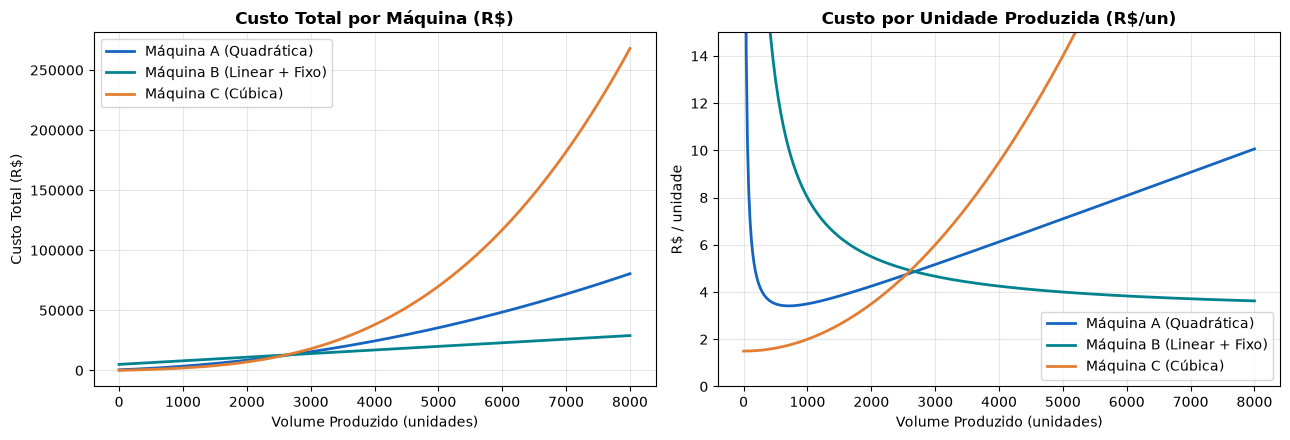

Intuição de Negócio:
- Maquina C: Imbativel em volumes pequenos (< 1.000-1.500 un), mas explode em volumes altos.
- Maquina A: Muito equilibrada para volumes medios (1.500 a 3.000 un).
- Maquina B: Cara para ligar (R$ 5.000), mas ideal para absorver grandes volumes.


In [7]:
# Análise gráfica dos custos de máquinas

DEMANDA = 10000

# Função de Custo Total (assumindo a máquina já ligada)
def custo_A(p): return 0.001 * p**2 + 2 * p + 500    # Quadrática
def custo_B(p): return 3 * p + 5000                   # Linear (custo fixo alto)
def custo_C(p): return 0.0000005 * p**3 + 1.5 * p     # Cúbica

p = np.linspace(1, 8000, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Custo Total
ax1.plot(p, custo_A(p), label='Máquina A (Quadrática)', color='#1565C0', lw=2)
ax1.plot(p, custo_B(p), label='Máquina B (Linear + Fixo)', color='#00838F', lw=2)
ax1.plot(p, custo_C(p), label='Máquina C (Cúbica)', color='#E27D32', lw=2)
ax1.set_title('Custo Total por Máquina (R$)', fontweight='bold')
ax1.set_xlabel('Volume Produzido (unidades)')
ax1.set_ylabel('Custo Total (R$)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Custo unitário médio
ax2.plot(p, custo_A(p) / p, label='Máquina A (Quadrática)', color='#1565C0', lw=2)
ax2.plot(p, custo_B(p) / p, label='Máquina B (Linear + Fixo)', color='#00838F', lw=2)
ax2.plot(p, custo_C(p) / p, label='Máquina C (Cúbica)', color='#E27D32', lw=2)
ax2.set_title('Custo por Unidade Produzida (R$/un)', fontweight='bold')
ax2.set_xlabel('Volume Produzido (unidades)')
ax2.set_ylabel('R$ / unidade')
ax2.set_ylim(0, 15)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Intuição de Negócio:")
print("- Maquina C: Imbativel em volumes pequenos (< 1.000-1.500 un), mas explode em volumes altos.")
print("- Maquina A: Muito equilibrada para volumes medios (1.500 a 3.000 un).")
print("- Maquina B: Cara para ligar (R$ 5.000), mas ideal para absorver grandes volumes.")

## 4. Modelagem do problema MINLP

A pergunta real não é "qual máquina" e sim "**quais** máquinas ligar e **quanto** produzir em cada uma para atender a demanda ao menor custo total?".

Para cada máquina `i` temos duas variáveis:

- `p[i]` (contínua, ≥ 0): quantidade produzida na máquina `i`
- `y[i]` (binária, 0 ou 1): se a máquina `i` está ligada

O custo fixo de cada máquina só deve entrar na conta se ela **de fato for usada** — por isso ele é multiplicado por `y[i]`, e não somado incondicionalmente como na função `custo_X` da seção anterior (que assumia a máquina sempre ligada).

Restrições:
- `p[i] <= DEMANDA * y[i]` (a máquina só pode produzir se estiver ligada — "Big-M")
- `soma(p[i]) == DEMANDA` (a demanda total precisa ser atendida)

Objetivo: minimizar o custo total (variável + fixo) somado entre as três máquinas.

In [8]:
MAQUINAS = ['A', 'B', 'C']
CUSTO_FIXO = {'A': 500, 'B': 5000, 'C': 0}


def custo_variavel(nome, p):
    """Parte do custo que depende do volume produzido (sem o custo fixo)."""
    if nome == 'A':
        return 0.001 * p**2 + 2 * p
    if nome == 'B':
        return 3 * p
    if nome == 'C':
        return 0.0000005 * p**3 + 1.5 * p


def criar_modelo_fabrica(demanda=DEMANDA):
    """Cria o modelo MINLP: quais máquinas ligar e quanto produzir em cada uma."""
    m = pyo.ConcreteModel()
    m.setMaq = pyo.Set(initialize=MAQUINAS)
    m.Demanda = demanda

    m.p = pyo.Var(m.setMaq, bounds=(0, None))       # producao por maquina
    m.y = pyo.Var(m.setMaq, domain=pyo.Binary)       # maquina ligada?

    # Funcao objetivo: minimizar custo total (variavel + fixo, se ligada)
    m.obj = pyo.Objective(
        expr=sum(custo_variavel(i, m.p[i]) + CUSTO_FIXO[i] * m.y[i] for i in m.setMaq),
        sense=pyo.minimize
    )

    # Restricao: demanda total atendida
    m.atende_demanda = pyo.Constraint(expr=sum(m.p[i] for i in m.setMaq) == m.Demanda)

    # Restricao de ligacao: so produz se a maquina estiver ligada (Big-M = demanda total)
    m.liga_maquina = pyo.ConstraintList()
    for i in m.setMaq:
        m.liga_maquina.add(m.p[i] <= m.Demanda * m.y[i])

    return m


modelo = criar_modelo_fabrica()
print("Modelo MINLP criado com sucesso!")
print(f"Variaveis continuas: p[A], p[B], p[C]  |  Variaveis binarias: y[A], y[B], y[C]")

Modelo MINLP criado com sucesso!
Variaveis continuas: p[A], p[B], p[C]  |  Variaveis binarias: y[A], y[B], y[C]


## 5. Por que precisamos do Couenne (e não do CBC ou do Ipopt)?

- **CBC** (Aula 1) só resolve problemas **lineares** — não entende `p²` nem `p³`.
- **Ipopt** (Aula 2) resolve problemas **não-lineares contínuos** — mas não sabe lidar com variáveis **binárias** (`y[i]`).
- **Couenne** é um solver de **MINLP** (Mixed-Integer NonLinear Programming): combina *branch-and-bound* (para as decisões binárias) com técnicas de otimização global para as partes não-lineares. É o único dos três que resolve esse modelo por completo.

In [9]:
opt_couenne = SolverFactory('couenne')
resultado = opt_couenne.solve(modelo, tee=False)

print(f"Status: {resultado.solver.termination_condition}")

print("\n=== DECISAO OTIMA DE PRODUCAO ===")
custo_total = 0
for i in MAQUINAS:
    p_i = pyo.value(modelo.p[i])
    ligada = pyo.value(modelo.y[i]) > 0.5
    if ligada:
        custo_i = custo_variavel(i, p_i) + CUSTO_FIXO[i]
        custo_total += custo_i
        print(f"  Maquina {i}: LIGADA  -> produz {p_i:>8,.0f} unidades  (custo: R$ {custo_i:>9,.2f})")
    else:
        print(f"  Maquina {i}: desligada -> produz {p_i:>8,.0f} unidades")

print(f"\nCUSTO TOTAL OTIMO: R$ {pyo.value(modelo.obj):,.2f}")

Status: optimal

=== DECISAO OTIMA DE PRODUCAO ===
  Maquina A: desligada -> produz        0 unidades
  Maquina B: LIGADA  -> produz    9,000 unidades  (custo: R$ 32,000.07)
  Maquina C: LIGADA  -> produz    1,000 unidades  (custo: R$  1,999.93)

CUSTO TOTAL OTIMO: R$ 34,000.00


## 6. Comparando com cenários ingênuos (uma única máquina)

Um gestor sem otimização provavelmente escolheria **uma única máquina** para produzir tudo. Vamos comparar esse tipo de decisão ingênua com a solução ótima (que pode combinar máquinas).

            Só A: R$   120,500.00
            Só B: R$    35,000.00
            Só C: R$   515,000.00
   Ótimo (MINLP): R$    34,000.00

Economia da solucao otima vs. a melhor opcao de maquina unica: R$ 1,000.00 (2.9%)


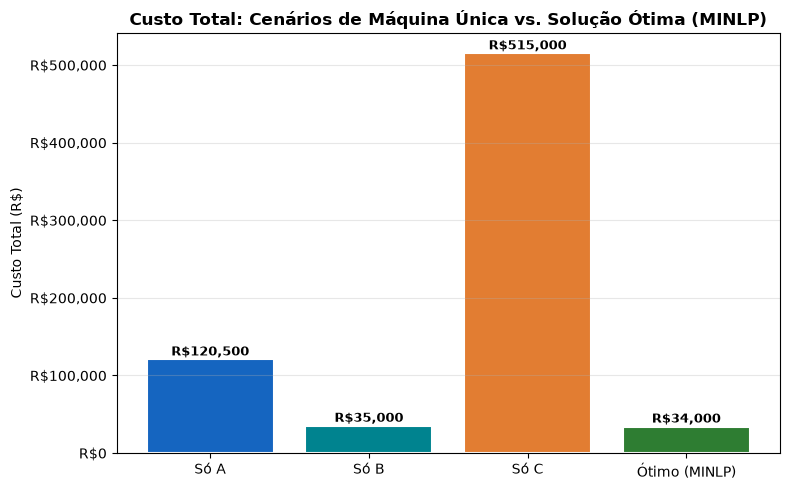

In [10]:
# Cenarios "ingenuos": produzir a demanda inteira em uma unica maquina
cenarios = {
    'Só A': custo_A(DEMANDA),
    'Só B': custo_B(DEMANDA),
    'Só C': custo_C(DEMANDA),
    'Ótimo (MINLP)': pyo.value(modelo.obj),
}

for nome, custo in cenarios.items():
    print(f"  {nome:>14s}: R$ {custo:>12,.2f}")

melhor_ingenuo = min(v for k, v in cenarios.items() if k != 'Ótimo (MINLP)')
economia = melhor_ingenuo - cenarios['Ótimo (MINLP)']
print(f"\nEconomia da solucao otima vs. a melhor opcao de maquina unica: "
      f"R$ {economia:,.2f} ({economia/melhor_ingenuo*100:.1f}%)")

# Grafico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
nomes = list(cenarios.keys())
valores = list(cenarios.values())
cores = ['#1565C0', '#00838F', '#E27D32', '#2E7D32']
barras = ax.bar(nomes, valores, color=cores, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Custo Total (R$)')
ax.set_title(f'Custo Total: Cenários de Máquina Única vs. Solução Ótima (MINLP)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v + max(valores)*0.01, f'R${v:,.0f}',
            ha='center', fontsize=9, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Conclusões

1. **A solução ótima combina máquinas**: o solver liga a máquina C só até o ponto em que ela ainda é barata (baixo volume) e completa o restante da demanda na máquina B, que tem custo fixo alto mas custo marginal baixo e constante — vantajoso em grandes volumes.
2. **A máquina A não entra na solução**: seu custo marginal cresce mais rápido do que o da B para o intervalo de volume relevante aqui, então nunca compensa liga-la neste cenário.
3. **Decisão binária + curva não-linear = MINLP**: esse tipo de problema (ligar/desligar recursos com curvas de custo não-lineares) aparece o tempo todo em planejamento de produção, dimensionamento de servidores, escalonamento de energia, etc.
4. **O solver certo importa**: CBC não entenderia as curvas não-lineares; Ipopt não entenderia as decisões binárias. Só um solver de MINLP como o Couenne resolve o problema completo.

### Conceitos-chave:
- **MINLP**: Mixed-Integer NonLinear Programming — variáveis binárias/inteiras *e* funções não-lineares no mesmo modelo.
- **Custo fixo condicional**: modelado com `custo_fixo * y[i]`, onde `y[i]` é uma variável binária.
- **Restrição Big-M**: `p[i] <= M * y[i]` é o truque clássico para "a variável contínua só pode ser positiva se a binária estiver ligada".